In [1]:
import requests
# APD Raw Data download link, from BSEE's Raw Data site
url = 'https://www.data.bsee.gov/Well/Files/eWellAPDRawData.zip'
destination = 'eWellAPDRawData.zip'

response = requests.get(url)
if response.status_code == 200:
    with open(destination, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded '{destination}' successfully.")
else:
    print(f"Failed to download file. Status code: {response.status_code}")

Downloaded 'eWellAPDRawData.zip' successfully.


The downloaded archive (eWellAPDRawData.zip) is then extracted locally for further processing.

In [2]:
import zipfile
import os

zip_file_path = destination      # The downloaded file
extract_dir = 'eWellAPDRawData'  # Directory to unzip data

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"Extracted contents of '{zip_file_path}' to '{extract_dir}'.")

Extracted contents of 'eWellAPDRawData.zip' to 'eWellAPDRawData'.


## 2. Data Loading and Initial Inspection

The raw APD text file is loaded into a ```pandas``` DataFrame (APD), which serves as the primary data structure for all subsequent filtering, aggregation, and visualization steps.


In [3]:
import pandas as pd
# Load APD data
APD = pd.read_csv("./eWellAPDRawData/eWellAPDRawData/mv_apd_main.txt",
                  encoding='latin1',
                  low_memory=False)
APD.head()

,SN_APD,API_WELL_NUMBER,MMS_COMPANY_NUM,KICKOFF_POINT_MD,WELL_NAME,WELL_NM_BP_SFIX,WELL_NM_ST_SFIX,WATER_DEPTH,PERMIT_TYPE,PRP_RKB_ELEV,...,RATED_WTR_DEPTH,RATE_DRIL_DEPTH,ABS_CERT_EXPR_DT,CG_CERT_EXPR_DT,SAFE_BRN_APRV_DT,SAFE_BURN_DIST,SAFE_BRN_RMK,BUS_ASC_NAME,APD_SUB_STATUS_DT,APD_STATUS_DT
0,-24381,608174144703,689,20433.0,PN003,1,2,4206,Revised Bypass,102,...,12000.0,40000.0,9/9/2025,7/27/2025,2/27/2018,GOMR New Orleans District,NaN,Shell Offshore Inc.,9/22/2022 9:49:33 PM,9/23/2022 3:43:22 PM
1,-24376,608174144703,689,20433.0,PN003,1,2,4206,Revised Bypass,102,...,12000.0,40000.0,9/9/2025,7/27/2025,2/27/2018,GOMR New Orleans District,NaN,Shell Offshore Inc.,9/21/2022 4:21:01 PM,9/22/2022 12:00:43 PM
2,-25262,608054010101,689,15600.0,WS502,0,1,9058,Revised Sidetrack,102,...,12000.0,40000.0,9/9/2025,7/27/2025,2/27/2018,GOMR New Orleans District,NaN,Shell Offshore Inc.,8/8/2023 11:02:52 AM,8/18/2023 12:49:05 PM
3,-27266,608054011500,689,NaN,WS304,0,0,8556,Revised New Well,102,...,12000.0,40000.0,9/9/2025,7/27/2025,2/27/2018,GOMR New Orleans District,NaN,Shell Offshore Inc.,9/29/2025 7:58:13 AM,10/23/2025 3:03:53 PM
4,-27258,608054010800,689,NaN,WS401,0,0,8825,Revised New Well,102,...,12000.0,40000.0,9/9/2025,7/27/2025,2/27/2018,GOMR New Orleans District,NaN,Shell Offshore Inc.,9/12/2025 8:08:49 AM,9/12/2025 10:58:31 AM


An initial inspection confirms the presence of approximately 60+ columns describing permit, operator, rig, and location attributes. Early validation at this stage is critical in drilling analytics workflows, as unit inconsistencies, missing coordinates, or malformed dates can propagate downstream and distort spatial or temporal interpretations.

To understand dataset scale and potential duplication, unique wells are inspected using the assigned API well number.

In [4]:
# Inspect number of wells in dataset, filtering unique values within API_WELL_NUMBER
# There may be more than one permit per well number
print(f'Number of unique wells, based on assigned API well number, in APD dataset: {len(APD['API_WELL_NUMBER'].unique())}')
# Inspect columns included in APD dataset
print(f'Columns included in APD dataset: {APD.columns}.')

Number of unique wells, based on assigned API well number, in APD dataset: 6253
Columns included in APD dataset: Index(['SN_APD', 'API_WELL_NUMBER', 'MMS_COMPANY_NUM', 'KICKOFF_POINT_MD',
       'WELL_NAME', 'WELL_NM_BP_SFIX', 'WELL_NM_ST_SFIX', 'WATER_DEPTH',
       'PERMIT_TYPE', 'PRP_RKB_ELEV', 'MINERAL_CODE', 'REQ_SPUD_DATE',
       'SUBSEA_BOP_FLAG', 'WELL_TYPE_CODE', 'DRIVE_DEPTH', 'DRIVE_SIZE',
       'SURF_AREA_CODE', 'SURF_BLOCK_NUMBER', 'SURF_LEASE_NUMBER',
       'SURF_STATE_LEASE_NUM', 'SURF_X_COORD_LOC', 'SURF_Y_COORD_LOC',
       'SURF_LATITUDE', 'SURF_LONGITUDE', 'SURF_E_W_DISTANCE', 'SURF_E_W_CODE',
       'SURF_N_S_DISTANCE', 'SURF_N_S_CODE', 'BOTM_AREA_CODE',
       'BOTM_BLOCK_NUMBER', 'BOTM_LEASE_NUMBER', 'BOTM_STATE_LEASE_NUM',
       'SV_PLAN_CTRL_CD', 'SV_PLAN_CTRL_NUM', 'SV_SURF_LEASE_NUM',
       'SV_SURF_AREA_CODE', 'SV_SURF_BLOCK_NUM', 'SV_WELL_NAME',
       'BV_PLAN_CTRL_CD', 'BV_PLAN_CTRL_NUM', 'BV_BOTM_LEASE_NUM',
       'BV_BOTM_AREA_CODE', 'BV_BOTM_BLOCK

## 3. Data Conditioning and Temporal Normalization

The APD dataset contains multiple date-related fields stored as strings or numeric values. These fields are systematically converted to ```datetime``` format to enable robust time-based filtering, sorting, and aggregation.

Subsequently, a date-based filter (```date_mask```) is applied to restrict the dataset to wells approved within the last 12 months. This rolling time window focuses the visualization on recent permitting activity and prevents older approvals from obscuring spatial trends on the map. From a practical standpoint, this approach aligns the dashboard with near-term planning and monitoring use cases, rather than long-term historical analysis.

In [5]:
# Convert date columns to datetime format
date_cols = []
for col in APD.columns:
  if ('DATE' in col) or ('DT' in col):
    date_cols.append(col)
APD[date_cols] = APD[date_cols].apply(pd.to_datetime, errors='coerce')

# Filter only wells from the last 12 months from present date
current_date = pd.Timestamp.now()
date_12_months_ago = current_date - pd.DateOffset(months=12)

date_mask = (APD['APD_STATUS_DT'] > date_12_months_ago) # wells where approval date is after 12 months ago
APD = APD[date_mask].copy()
# Inspect remaining number of wells for last 12 months
print(f'Number of unique wells over the last 12 months,\nbased on assigned API well number, in APD dataset: {APD['API_WELL_NUMBER'].nunique()}')

C:\Users\sc67252\AppData\Local\Temp\ipykernel_33872\634902341.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  APD[date_cols] = APD[date_cols].apply(pd.to_datetime, errors='coerce')
C:\Users\sc67252\AppData\Local\Temp\ipykernel_33872\634902341.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  APD[date_cols] = APD[date_cols].apply(pd.to_datetime, errors='coerce')


Number of unique wells over the last 12 months,
based on assigned API well number, in APD dataset: 158


This filtering step ensures that the resulting map remains interpretable while still capturing the current spatial distribution of offshore drilling activity in the Gulf of Mexico.

In [28]:
APD.info()

<class 'pandas.DataFrame'>
Index: 727 entries, 3 to 19692
Data columns (total 62 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   SN_APD                727 non-null    int64         
 1   API_WELL_NUMBER       727 non-null    int64         
 2   MMS_COMPANY_NUM       727 non-null    int64         
 3   KICKOFF_POINT_MD      252 non-null    float64       
 4   WELL_NAME             727 non-null    str           
 5   WELL_NM_BP_SFIX       727 non-null    int64         
 6   WELL_NM_ST_SFIX       727 non-null    int64         
 7   WATER_DEPTH           727 non-null    int64         
 8   PERMIT_TYPE           727 non-null    str           
 9   PRP_RKB_ELEV          727 non-null    int64         
 10  MINERAL_CODE          727 non-null    str           
 11  REQ_SPUD_DATE         727 non-null    datetime64[us]
 12  SUBSEA_BOP_FLAG       727 non-null    str           
 13  WELL_TYPE_CODE        727 non-null

## 4. Interactive Map Construction with Plotly
### 4.1 Map Scope and Coordinate Conditioning

Prior to visualization, the dataset is filtered to remove records lacking valid surface coordinates (columns ```'SURF_LATITUDE', 'SURF_LONGITUDE'```). Latitude and longitude ranges are constrained to the Gulf of Mexico to prevent plotting spurious or malformed records.

In [6]:
# Clean coordinates: ensure valid lat/long
APD_map = APD.dropna(subset=['SURF_LATITUDE', 'SURF_LONGITUDE'])
APD_map = APD_map[(APD_map['SURF_LATITUDE'].between(20, 35)) &  # Rough Gulf of Mexico bounds
                  (APD_map['SURF_LONGITUDE'].between(-100, -80))]

### 4.2 Dynamic Title Generation

To improve interpretability and reproducibility, the map title is dynamically generated based on the temporal extent of the data.

In [29]:
# Set dynamic plot title, to update based on start and end date
# Dates are formated as Month-Year (e.g., Jan-25)
date_min      = APD['APD_STATUS_DT'].min().strftime('%b-%y') # Start date as Month-Year
date_max      = APD['APD_STATUS_DT'].max().strftime('%b-%y') # End date as Month-Year
dynamic_title = f'Gulf of Mexico (GoM) eWell APD Approvals ({date_min} to {date_max})'
# Display dynamic title string
print(dynamic_title)

Gulf of Mexico (GoM) eWell APD Approvals (Apr-25 to Apr-26)


### 4.3 Scatter Map Visualization

Plotly’s ```scatter_map``` interface is used to render approved APDs as georeferenced points. Water depth is encoded using a continuous color scale (```Blues```), enabling immediate visual differentiation between shallow-water, shelf, and deepwater operations—an operationally meaningful distinction for drilling and MPD planning.

In [30]:
# Render any plots in a way that is suitable for multiple environments.
# The plotly_mimetype renderer is suitable for viewing the source notebook within Jupyter Lab.
# The notebook_connected renderer is necessary for the plot to appear in the Jekyll site.
import plotly.io as pio
pio.renderers.default = "notebook_connected+plotly_mimetype"

In [31]:
import plotly.express as px

# Create hover text
APD_map['hover_text'] = (
    "Well: " + APD_map['WELL_NAME'].astype(str) + "<br>" +
    "API: " + APD_map['API_WELL_NUMBER'].astype(str) + "<br>" +
    "Operator: " + APD_map['BUS_ASC_NAME'].astype(str) + "<br>" +
    "Rig: " + APD_map['RIG_NAME'].astype(str) + "<br>" +
    "Rig Type: " + APD_map['RIG_TYPE_CODE'].astype(str) + "<br>" +
    "Water Depth: " + APD_map['WATER_DEPTH'].astype(str) + " ft<br>" +
    "Approved: " + APD_map['APD_STATUS_DT'].astype(str)
)

# Plotly scatter map
fig = px.scatter_map(
    APD_map,
    lat="SURF_LATITUDE",
    lon="SURF_LONGITUDE",
    hover_name="WELL_NAME",
    hover_data={"hover_text": False},  # Use custom hover
    color="WATER_DEPTH",  # Color by declared water depth (change to 'WATER_DEPTH' for continuous)
    size_max=25,
    zoom=5.5,
    height=700,
    title=dynamic_title
)

fig.update_traces(
    hovertemplate=APD_map['hover_text']
)

fig.update_layout(
    mapbox_style="open-street-map",  # Free, no token needed
    margin={"r":0,"t":40,"l":0,"b":0},
    coloraxis=dict(colorscale="Blues",
                   colorbar=dict(title="Water Depth (ft)")) # Set "Blues" colorscale
)
# fig.write_html("bsee-map-water-depth.html")
fig.show()

<small>*Source: <a href="https://www.data.bsee.gov/Well/eWellAPD/Default.aspx">BSEE eWell APD database</a>.
Water depth encoded via color scale (ft).
  Hover for well and rig details; zoom and selection tools available in the upper-left.*
</small>

Embedding rich metadata in hover tooltips (```'hover_text'``` definition) allows engineers to interrogate individual wells without cluttering the map, closely aligning with how operational dashboards are used in practice.

# 5. Exploratory Analysis Using pandas

Beyond visualization, the APD dataset supports rapid exploratory analysis of offshore activity trends. As an example, operator-level and rig-type-level summaries are generated using ```pandas groupby``` aggregations.

For this example, the ```pandas``` library is used to perform data aggregation and to display summary tables. The ```groupby``` functionality is applied to aggregate the dataset by selected operational attributes, enabling rapid inspection of activity levels and depth exposure across operators. The resulting tables are formatted to improve readability and interpretability.

As an initial summary, a table is generated to quantify unique well activity and average water depth by operator. The company name field (```'BUS_ASC_NAME'```) is used as the grouping key. For each operator, the number of unique wells is computed based on the ```'WELL_NAME'``` field, and the mean water depth is calculated from the ```'WATER_DEPTH'``` field. This aggregation provides a concise view of operator activity levels and the typical water depth regime in which each operator is active.

In [32]:
# Use the company name (BUS_ASC_NAME) to group by
# and count unique well names, and calculate mean water depth
unique_wells_by_company = APD.groupby('BUS_ASC_NAME').agg(
    Unique_Well_Name_Count=('WELL_NAME', 'nunique'),
    Mean_Water_Depth=('WATER_DEPTH', 'mean')
).reset_index()
# Sort by Unique_Well_Name_Count descending
unique_wells_by_company = unique_wells_by_company.sort_values(by='Unique_Well_Name_Count', ascending=False).reset_index(drop=True)
# Rename columns for better display
unique_wells_by_company.columns = ['Company_Name', 'Unique_Well_Name_Count', 'Mean_Water_Depth']
# Format Mean_Water_Depth with commas and no decimal places
unique_wells_by_company['Mean_Water_Depth'] = unique_wells_by_company['Mean_Water_Depth'].map('{:,.0f}'.format)
# Display the table output
display(unique_wells_by_company)

,Company_Name,Unique_Well_Name_Count,Mean_Water_Depth
0,Shell Offshore Inc.,43,"6,173"
1,"Arena Offshore, LP",23,161
2,BP Exploration & Production Inc.,11,"5,144"
3,"Cantium, LLC",10,61
4,Chevron U.S.A. Inc.,8,"4,963"
5,Anadarko Petroleum Corporation,5,"5,983"
6,BOE Exploration & Production LLC,4,"5,739"
7,Murphy Exploration & Production Company - USA,4,"6,811"
8,"Beacon Growthco Operating Company, L.L.C.",2,"3,653"
9,Hess Corporation,2,"2,172"


This operator-level summary complements the spatial visualization by linking permitting activity to operator behavior and water-depth exposure, which is particularly relevant for assessing deepwater focus, rig class requirements, and potential MPD applicability.



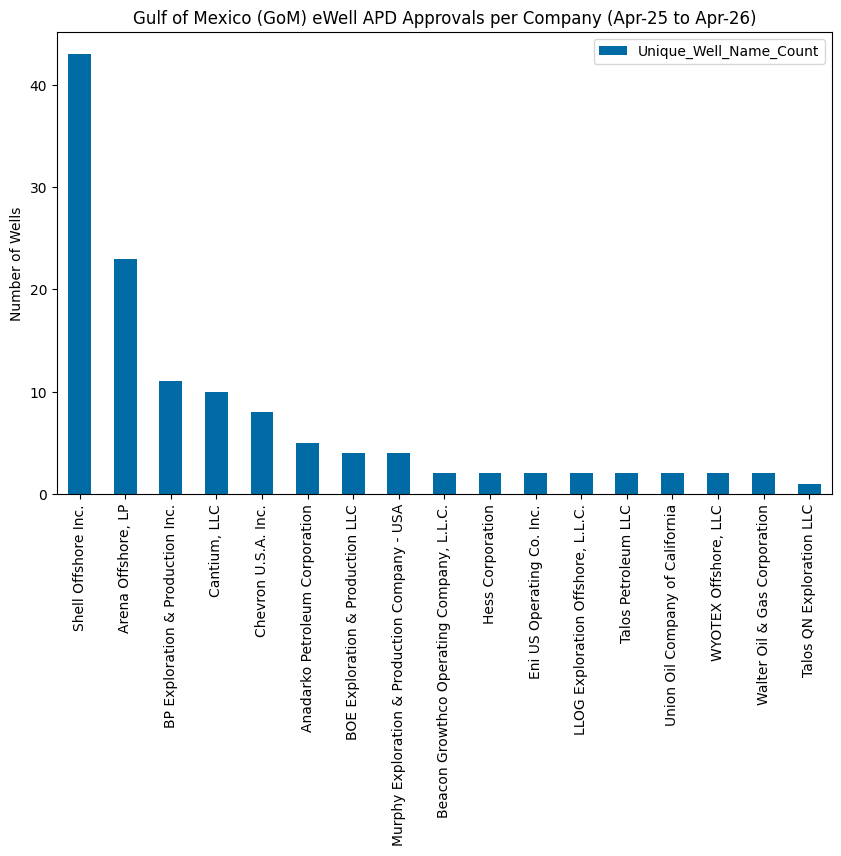

In [33]:
import matplotlib.pyplot as plt

dynamic_title = f'Gulf of Mexico (GoM) eWell APD Approvals per Company ({date_min} to {date_max})'
# Number of approved wells by company barplot
ax = unique_wells_by_company[['Company_Name', 'Unique_Well_Name_Count']].plot(kind='bar', figsize=[10,10*.6])
ax.set_xticklabels([company for company in unique_wells_by_company['Company_Name'].values])
ax.set_title(dynamic_title)
ax.set_ylabel('Number of Wells')
plt.show()

<small>*Bar chart showing the number of unique BSEE-approved APDs per operator in the Gulf of Mexico over the selected time window. The plot highlights relative permitting activity by company and complements the operator-level water depth statistics presented above.*</small>

### 5.2 Rig Type Summary
To further contextualize the permitting activity, the dataset is aggregated by rig type to evaluate how approved wells are distributed across different rig classes and associated water-depth regimes. This perspective is particularly relevant for understanding fleet composition, capability requirements, and the prevalence of deepwater versus shelf drilling programs.

The rig type code (```'RIG_TYPE_CODE'```) is used as the grouping key. For each rig type, the number of unique rigs is calculated based on the ```'RIG_NAME'``` field, and the mean water depth is computed from the ```'WATER_DEPTH'``` field. This aggregation provides insight into both the diversity of rig assets supporting recent APD approvals and the typical operating environments associated with each rig class.

In [34]:
# Use the rig type code (RIG_TYPE_CODE) to group by
# and count unique rig names, and calculate mean water depth
unique_rig_info_by_type = APD.groupby('RIG_TYPE_CODE').agg(
                              Unique_RIG_NAME_Count=('RIG_NAME', 'nunique'),
                              Mean_Water_Depth=('WATER_DEPTH', 'mean')
                          ).reset_index()
# Sort by Unique_RIG_NAME_Count descending
unique_rig_info_by_type = unique_rig_info_by_type.sort_values(by='Unique_RIG_NAME_Count', ascending=False).reset_index(drop=True)
# Rename columns for better display
unique_rig_info_by_type.columns = ['Rig_Type_Code', 'Unique_RIG_NAME_Count', 'Mean_Water_Depth']
# Format Mean_Water_Depth with commas and no decimal places
unique_rig_info_by_type['Mean_Water_Depth'] = unique_rig_info_by_type['Mean_Water_Depth'].\
                                              map('{:,.0f}'.format)
# Display the table output
display(unique_rig_info_by_type)

,Rig_Type_Code,Unique_RIG_NAME_Count,Mean_Water_Depth
0,DRILLSHIP,20,"5,548"
1,PLATFORM,9,"4,662"
2,JACKUP,5,115
3,DP SEMISUBMERSIBLE,1,"1,483"


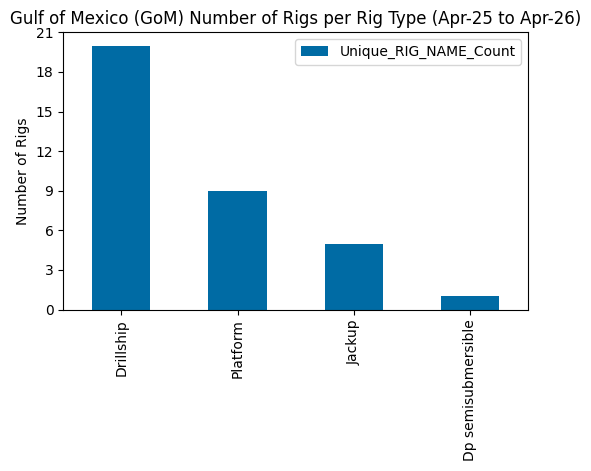

In [35]:
import matplotlib.ticker as ticker

dynamic_title = f'Gulf of Mexico (GoM) Number of Rigs per Rig Type ({date_min} to {date_max})'
# Number of rigs per rig type, barplot
ax = unique_rig_info_by_type[['Rig_Type_Code', 'Unique_RIG_NAME_Count']].plot(kind='bar', figsize=[6,6*.6])
ax.set_xticklabels([rig.lower().capitalize() for rig in unique_rig_info_by_type['Rig_Type_Code'].values])
ax.set_title(dynamic_title)
ax.set_ylabel('Number of Rigs')
# Force the y-axis to use integer labels
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.show()

<small>*Bar chart showing the number of unique rigs by rig type associated with BSEE-approved APDs in the Gulf of Mexico over the selected time window. The plot highlights the distribution of rig classes supporting recent permitting activity and provides context on fleet composition across water-depth regimes.*</small>

This rig-type-level summary complements the operator-based analysis by linking permitting activity to rig capability and water depth exposure. When combined with the spatial map and operator statistics, it helps identify whether recent approvals are primarily supported by specific rig classes—such as deepwater floaters versus shelf jack-ups—which has direct implications for rig availability, MPD applicability, and near-term drilling risk profiles.

### 5.3 Rigs per Operator Summary
To further contextualize the permitting activity, the dataset is aggregated by both operator and rig type to evaluate how approved wells are distributed across different rig classes and associated water-depth regimes for each operator. This perspective is particularly relevant for understanding fleet composition, capability requirements, and the prevalence of deepwater versus shelf drilling programs across operators.

In [36]:
# Use the company name (BUS_ASC_NAME) to group by
# and count unique well names, and calculate mean water depth
unique_wells_by_company = APD.groupby('BUS_ASC_NAME').agg(
    Unique_Rig_Name_Count=('RIG_NAME', 'nunique'),
    Mean_Water_Depth=('WATER_DEPTH', 'mean')
).reset_index()
# Sort by Unique_Well_Name_Count descending
unique_wells_by_company = unique_wells_by_company.sort_values(by='Unique_Rig_Name_Count', ascending=False).reset_index(drop=True)
# # Rename columns for better display
unique_wells_by_company.columns = ['Company_Name', 'Unique_Rig_Name_Count', 'Mean_Water_Depth']
# # Format Mean_Water_Depth with commas and no decimal places
unique_wells_by_company['Mean_Water_Depth'] = unique_wells_by_company['Mean_Water_Depth'].map('{:,.0f}'.format)
# Display the table output
display(unique_wells_by_company)

,Company_Name,Unique_Rig_Name_Count,Mean_Water_Depth
0,Shell Offshore Inc.,9,"6,173"
1,BP Exploration & Production Inc.,6,"5,144"
2,Chevron U.S.A. Inc.,5,"4,963"
3,"Arena Offshore, LP",4,161
4,Walter Oil & Gas Corporation,3,"1,687"
5,Anadarko Petroleum Corporation,2,"5,983"
6,BOE Exploration & Production LLC,2,"5,739"
7,"Beacon Growthco Operating Company, L.L.C.",2,"3,653"
8,"Cantium, LLC",1,61
9,Hess Corporation,1,"2,172"


In [37]:
unique_wells_by_company = APD.groupby(['BUS_ASC_NAME','RIG_TYPE_CODE']).agg(
    Unique_Rig_Name_Count=('RIG_NAME', 'nunique'),
    Mean_Water_Depth=('WATER_DEPTH', 'mean')
).reset_index()
display(unique_wells_by_company)

,BUS_ASC_NAME,RIG_TYPE_CODE,Unique_Rig_Name_Count,Mean_Water_Depth
0,Anadarko Petroleum Corporation,DRILLSHIP,2,5982.929825
1,"Arena Offshore, LP",JACKUP,4,160.688889
2,BOE Exploration & Production LLC,DRILLSHIP,2,5738.809524
3,BP Exploration & Production Inc.,DRILLSHIP,4,5093.362745
4,BP Exploration & Production Inc.,PLATFORM,2,5310.354839
5,"Beacon Growthco Operating Company, L.L.C.",DRILLSHIP,2,3652.800000
6,"Cantium, LLC",JACKUP,1,61.157895
7,Chevron U.S.A. Inc.,DRILLSHIP,4,4919.985507
8,Chevron U.S.A. Inc.,PLATFORM,1,5189.000000
9,Eni US Operating Co. Inc.,PLATFORM,1,5610.000000


In [38]:
display(unique_wells_by_company.pivot(index='BUS_ASC_NAME', columns='RIG_TYPE_CODE', values='Unique_Rig_Name_Count').fillna(0).astype(int))

RIG_TYPE_CODE,DP SEMISUBMERSIBLE,DRILLSHIP,JACKUP,PLATFORM
BUS_ASC_NAME,,,,
Anadarko Petroleum Corporation,0,2,0,0
"Arena Offshore, LP",0,0,4,0
BOE Exploration & Production LLC,0,2,0,0
BP Exploration & Production Inc.,0,4,0,2
"Beacon Growthco Operating Company, L.L.C.",0,2,0,0
"Cantium, LLC",0,0,1,0
Chevron U.S.A. Inc.,0,4,0,1
Eni US Operating Co. Inc.,0,0,0,1
Hess Corporation,0,1,0,0


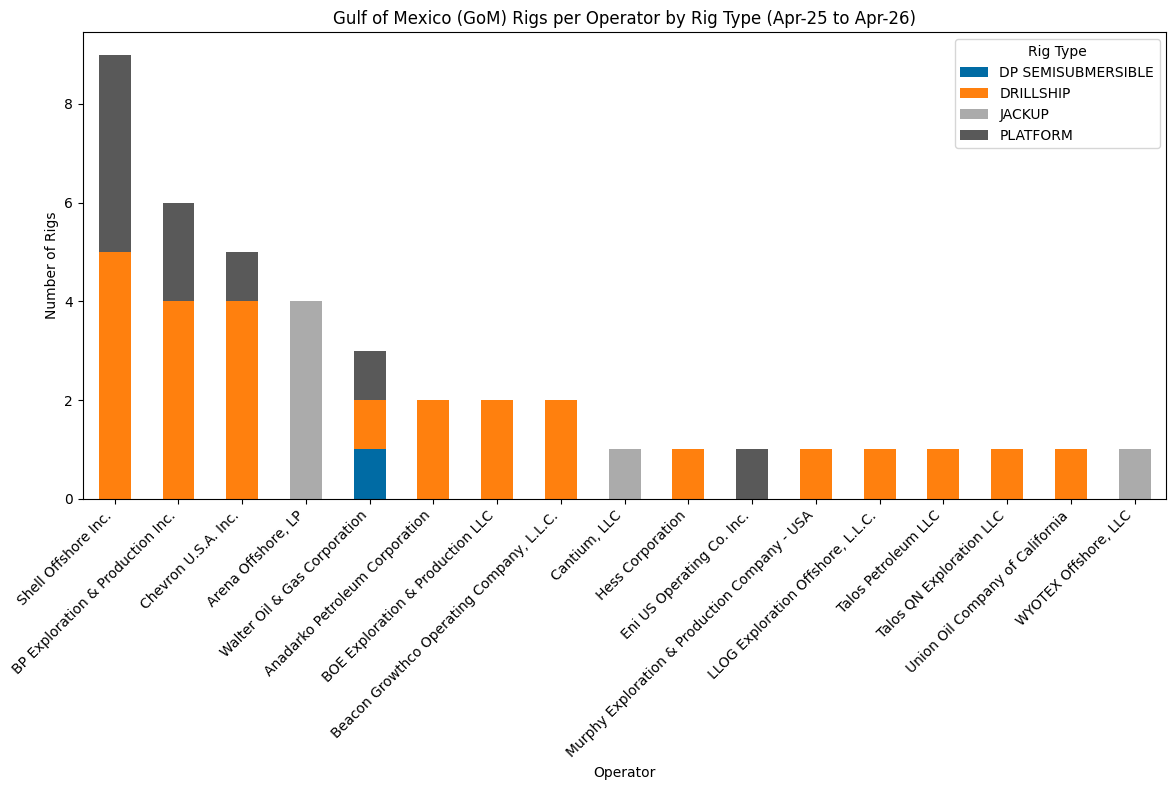

In [39]:
import matplotlib.pyplot as plt
import matplotlib.style as style
from matplotlib.ticker import FuncFormatter
style.use('tableau-colorblind10')
#style.use('seaborn-notebook')
# style.use('seaborn-whitegrid')

# plt.rcParams['font.family'] = 'Times New Roman'
# mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['ps.fonttype'] = 42
# mpl.rcParams['font.family'] = 'Arial'
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Create the pivoted dataframe
pivoted = unique_wells_by_company.pivot(index='BUS_ASC_NAME', columns='RIG_TYPE_CODE', values='Unique_Rig_Name_Count').fillna(0).astype(int)

# Sort companies by total rigs descending
pivoted['Total'] = pivoted.sum(axis=1)
pivoted = pivoted.sort_values('Total', ascending=False).drop('Total', axis=1)

# Plot stacked bar
ax = pivoted.plot(kind='bar', stacked=True, figsize=(12, 8))
ax.set_title(f'Gulf of Mexico (GoM) Rigs per Operator by Rig Type ({date_min} to {date_max})')
ax.set_ylabel('Number of Rigs')
ax.set_xlabel('Operator')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rig Type')
plt.tight_layout()
plt.show()

<small>*Stacked bar chart showing the number of unique rigs by rig type for each operator associated with BSEE-approved APDs in the Gulf of Mexico over the selected time window. The plot highlights the distribution of rig classes per operator and provides context on fleet composition across companies.*</small>
